<a href="https://colab.research.google.com/github/Youssef-Chip/lab1/blob/main/lab4/check1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM Scaling Laws

## Part A: Experimental Setup

In [10]:
"""
Downloading the data
"""
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

response = requests.get(url)
text = response.text

print(f"Dataset Downloaded. Total characters: {len(text)}")
print("--- First 100 characters ---")
print(text[:100])

Dataset Downloaded. Total characters: 1115394
--- First 100 characters ---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [11]:
"""
Building a feed-forward NN model
"""
import torch
import torch.nn as nn
import torch.nn.functional as F

class TinyLLM(nn.Module):
  """
  Feed-Forward NN model
  """
  def __init__(self, vocab_size, embed_size, hidden_size, context_length):
    """
    Consists of the embedding layer, hidden layer, and output layer
    Parameters:
      - vocab_size: Total unique characters in our dataset
      - embed_size: Size of the embedding layer.
      - hidden_size: Number of neurons in the hidden layer
      - context_length: How many past characters we look at
    """
    super(TinyLLM, self).__init__()
    # The Embedding Layer (Character Lookup Table)
    self.embedding = nn.Embedding(vocab_size, embed_size)
    # The Hidden Layer
    self.hidden = nn.Linear(context_length * embed_size, hidden_size)
    # The Output Layer
    self.output = nn.Linear(hidden_size, vocab_size)

  def forward(self, x):
    """
    Forward pass of the model. Takes in a batch of character sequences at a time
    for efficiency
    Parameters:
      - x: Batch of input character sequences. The shape of x is
           (batch_size, context_length)
    """
    # Convert integer tokens to dense vectors
    embeds = self.embedding(x)
    # Shape becomes: (batch_size, context_length, embed_size)

    # Flatten the vectors to feed into the linear layer
    embeds_flat = embeds.view(embeds.shape[0], -1)
    # Shape becomes: (batch_size, context_length * embed_size)

    # Pass through the hidden layer and apply ReLU activation function
    hidden = F.relu(self.hidden(embeds_flat))
    # Shape becomes: (batch_size, hidden_size)

    # Generate the final predictions
    logits = self.output(hidden)
    # Shape becomes: (batch_size, vocab_size)

    return logits

In [13]:
"""
TOKENIZING THE CORPUS
"""
import torch

# Build the vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Our vocabulary has {vocab_size} unique characters")

# Create translation dictionaries
stoi = {ch:i for i, ch in enumerate(chars)}
itos = {i:ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join([itos[i] for i in l])

# Encode the entire dataset
data = torch.tensor(encode(text), dtype=torch.long)

# Split the data (90% train, 10% validation)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Training data size: {len(train_data)} tokens")
print(f"Validation data size: {len(val_data)} tokens")

Our vocabulary has 65 unique characters
Training data size: 1003854 tokens
Validation data size: 111540 tokens


In [19]:
"""
BATCH LOADER
"""
torch.manual_seed(1337)

BATCH_SIZE = 32
CONTEXT_LENGTH = 8

def get_batch(split):
  """
  Function to take batches of data from training or validation set
  """
  data_source = train_data if split == "train" else val_data

  # Generate "batch_size" random starting points in the dataset
  ix = torch.randint(len(data_source) - CONTEXT_LENGTH, (BATCH_SIZE, ))

  # Take out the context (X) and the single target (Y) right after the context
  x = torch.stack([data_source[i : i+CONTEXT_LENGTH] for i in ix])
  y = torch.stack([data_source[i+CONTEXT_LENGTH] for i in ix])

  return x,y

# Testing function
X_batch, Y_batch = get_batch("train")
print(f"Input batch shape: {X_batch.shape}")
print(f"Target batch shape: {Y_batch.shape}")

Input batch shape: torch.Size([32, 8])
Target batch shape: torch.Size([32])


In [16]:
@torch.no_grad()
def estimate_loss(model, eval_iters=100):
  out = {}
  model.eval()

  for split in ["train", "val"]:
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
      X, Y = get_batch(split)
      logits = model(X)
      # We calculate loss exactly like we do in training
      loss = nn.CrossEntropyLoss()(logits, Y)
      losses[k] = loss.item()
    out[split] = losses.mean().item() # Average the loss over all eval batches

  model.train()
  return out

In [20]:
"""
MASTER EXPERIMENT LOOP
"""
import time
import math
import pandas as pd

# Define the 6 experimental configurations
experiments = [
    {"hidden_size": 64, "max_steps": 2000},  # Small model, short training
    {"hidden_size": 64, "max_steps": 6000}, # Small model, long training
    {"hidden_size": 128, "max_steps": 2000},  # Medium model, short training
    {"hidden_size": 128, "max_steps": 6000}, # Medium model, long training
    {"hidden_size": 256, "max_steps": 2000}, # Large model, short training
    {"hidden_size": 256, "max_steps": 6000} # Large model, long training
]

# A list to store our results
results = []
learning_rate = 0.001

for idx, config in enumerate(experiments):
  print(f"--- Running Experiment {idx+1}/6 ---")
  print(f"Config: Hidden Size: {config['hidden_size']}, Max Steps: {config['max_steps']}")

  # Initialize the model
  model = TinyLLM(vocab_size, embed_size=16, hidden_size=config["hidden_size"], context_length=8)
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  # Count the parameters
  num_params = sum(p.numel() for p in model.parameters())
  start_time = time.time()

  # Training loop
  for step in range(config["max_steps"]):
    Xb, Yb = get_batch("train")

    # Forward pass
    logits = model(Xb)

    # Calculate loss
    loss = nn.CrossEntropyLoss()(logits, Yb)

    # Backward pass & update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  end_time = time.time()

  # Evaulate the final, trained model
  eval_results = estimate_loss(model)
  val_loss = eval_results["val"]

  # Record the data
  results.append({
    "Model Size": f"Hidden_{config['hidden_size']}",
    "Parameters": num_params,
    "Training Steps": config['max_steps'],
    "Train Tokens": config['max_steps'] * 32 * 8, # steps * batch_size * context_length
    "Val Loss": val_loss,
    "Perplexity": math.exp(val_loss),
    "Time (sec)": round(end_time - start_time, 2)
  })
  print(f"Val Loss: {val_loss:.4f} | Time: {end_time - start_time:.2f}s")

--- Running Experiment 1/6 ---
Config: Hidden Size: 64, Max Steps: 2000
Val Loss: 2.3528 | Time: 5.23s
--- Running Experiment 2/6 ---
Config: Hidden Size: 64, Max Steps: 6000
Val Loss: 2.1116 | Time: 13.37s
--- Running Experiment 3/6 ---
Config: Hidden Size: 128, Max Steps: 2000
Val Loss: 2.2645 | Time: 5.05s
--- Running Experiment 4/6 ---
Config: Hidden Size: 128, Max Steps: 6000
Val Loss: 2.1201 | Time: 14.46s
--- Running Experiment 5/6 ---
Config: Hidden Size: 256, Max Steps: 2000
Val Loss: 2.2472 | Time: 5.81s
--- Running Experiment 6/6 ---
Config: Hidden Size: 256, Max Steps: 6000
Val Loss: 2.0498 | Time: 15.37s

--- Experiment Results ---
| Model Size   |   Parameters |   Training Steps |   Train Tokens |   Val Loss |   Perplexity |   Time (sec) |
|:-------------|-------------:|-----------------:|---------------:|-----------:|-------------:|-------------:|
| Hidden_64    |        13521 |             2000 |         512000 |    2.35279 |     10.5148  |         5.23 |
| Hidden_64   

## Part B: Required Measurements

In [21]:
# Convert results to a DataFrame for analysis
df = pd.DataFrame(results)
print("\n--- Experiment Results ---")
print(df.to_markdown(index=False))


--- Experiment Results ---
| Model Size   |   Parameters |   Training Steps |   Train Tokens |   Val Loss |   Perplexity |   Time (sec) |
|:-------------|-------------:|-----------------:|---------------:|-----------:|-------------:|-------------:|
| Hidden_64    |        13521 |             2000 |         512000 |    2.35279 |     10.5148  |         5.23 |
| Hidden_64    |        13521 |             6000 |        1536000 |    2.11158 |      8.26129 |        13.37 |
| Hidden_128   |        25937 |             2000 |         512000 |    2.2645  |      9.62628 |         5.05 |
| Hidden_128   |        25937 |             6000 |        1536000 |    2.12006 |      8.33167 |        14.46 |
| Hidden_256   |        50769 |             2000 |         512000 |    2.24716 |      9.4608  |         5.81 |
| Hidden_256   |        50769 |             6000 |        1536000 |    2.04977 |      7.76611 |        15.37 |


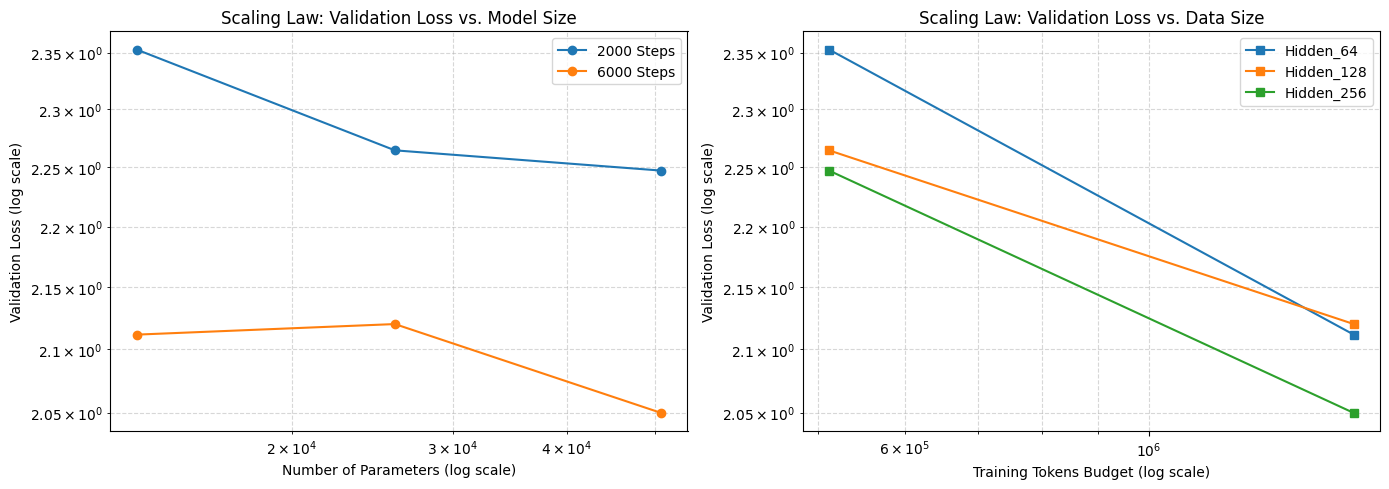

In [22]:
"""
PLOTTING LOG-LOG GRAPHS
"""
import matplotlib.pyplot as plt

# Set up figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Performance vs. Model Size (Parameters)
# Draw 2 lines: one for the 2000 step training and one for 6000 step training
for steps in df["Training Steps"].unique():
  subset = df[df["Training Steps"] == steps]
  axes[0].plot(subset["Parameters"], subset["Val Loss"], marker='o', label=f"{steps} Steps")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Scaling Law: Validation Loss vs. Model Size")
axes[0].set_xlabel("Number of Parameters (log scale)")
axes[0].set_ylabel("Validation Loss (log scale)")
axes[0].legend()
axes[0].grid(True, which="both", ls="--", alpha=0.5)

# Plot 2: Performance vs. Data Size (Train Tokens)
# Draw 3 lines for each model size
for hidden in df["Model Size"].unique():
  subset = df[df["Model Size"] == hidden]
  axes[1].plot(subset["Train Tokens"], subset["Val Loss"], marker='s', label=hidden)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Scaling Law: Validation Loss vs. Data Size')
axes[1].set_xlabel('Training Tokens Budget (log scale)')
axes[1].set_ylabel('Validation Loss (log scale)')
axes[1].legend()
axes[1].grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Consistency with Scaling Law Intuition
The results are consistent with scaling-law intuition (but there is some noise due to the toy setup):

In both of the log-log plots, there is a clear overall downward trend. As the data size increases (from 2000 to 6000 steps) or the model size increases (from 13k to 50k parameters), the validation loss generally decreases.

Small anomaly: In the validation Loss vs. Model Size, the 6000-step line has a slight bump upward at the middle model size (Hidden 128, Val Loss 2.12) compared to the smaller model (Hidden 64, Val Loss 2.11). However a possible explanation might be the learning rate (see Limitations below).

### Limitations
* **Fixed Learning Rate:** We used a fixed learning rate of `0.001` for all experiments, however larger models often require smaller learning rates, which is why the Hidden_128 model might have performed sub-optimally at 6000 steps because the learning rate wasn't tuned for it.
* **Undertraining / Model Architecture:** A feed-forward network with a context window of 8 characters can't capture longer patterns, compared to a transformer for example.

### Comparison at Roughly Equal Compute Budget

* **Smaller Model + More Data:** `Hidden_64` at `6000 steps`. 
  * 13,521 params × 6000 steps ≈ **81 million** operations.
  * *Val Loss:* **2.11**
* **Larger Model + Less Data:** `Hidden_256` at `2000 steps`.
  * 50,769 params × 2000 steps ≈ **101 million** operations.
  * *Val Loss:* **2.24**

Even though the larger model (`Hidden_256` at 2000 steps) actually used slightly *more* total compute operations (~101M vs ~81M), it performed **worse** than the smaller model trained on more data (Loss of 2.24 vs 2.11).
